<a href="https://colab.research.google.com/github/sirrom/Intelligent-Cloud-Resource-Optimization-System/blob/main/decision_trees_implementation_with_ID3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is a Decision Tree?
A **Decision Tree** is a supervised machine learning algorithm used for classification and regression tasks. It splits data into branches based on feature values, forming a tree-like structure that leads to a final decision or prediction.

# classification of decision trees

1.** Classification Tree**

A classification tree is used when the output (target variable) is categorical — meaning the prediction falls into a distinct class or group. It works by splitting the data based on features and assigning a class label at each leaf node. The splitting criteria commonly used are Information Gain (Entropy) and Gini Index.


Example: Predicting whether a patient has a disease — Yes or No. Predicting whether an email is Spam or Not Spam.

2**. Regression Tree**

A regression tree is used when the output is a continuous numerical value rather than a category. Instead of assigning a class label, the leaf node returns a mean or average value of the training instances that fall into that branch. The splitting criteria used is Mean Squared Error (MSE) or Mean Absolute Error (MAE).


Example: Predicting house prices, predicting a student's exam score, or forecasting temperature.


# How Does a Decision Tree Work?
The tree is built by recursively splitting the dataset based on the feature that best separates the data. The "best" feature is selected using a metric such as:

✅ Information Gain (used in ID3 algorithm)

✅ Gini Index (used in CART algorithm)

✅ Gain Ratio (used in C4.5 algorithm)


# Entropy
Before calculating Information Gain, we must understand Entropy — a measure of impurity or disorder in a dataset.

# Information Gain
Information Gain (IG) measures the reduction in entropy achieved by splitting the dataset on a particular feature. The feature with the highest information gain is chosen as the splitting node.



# implementation algorithms

** ID3 — Iterative Dichotomiser 3**

ID3 is one of the earliest and most fundamental decision tree algorithms developed by Ross Quinlan in 1986. It builds the tree top-down by selecting the feature with the highest Information Gain at each node. It only works with categorical features and does not handle missing values or continuous data natively.

Example: The Play Tennis dataset we worked on is a classic ID3 example.

   **C4.5 Tree**

C4.5 is an improved version of ID3 also developed by Quinlan. It overcomes ID3's limitations by handling both categorical and continuous attributes, managing missing values, and using Gain Ratio instead of Information Gain to avoid bias towards features with many values. It also performs pruning to reduce overfitting.

Example: Medical diagnosis systems and early data mining applications commonly used C4.5.

**CART — Classification and Regression Tree**

CART is a very popular algorithm that can build both classification and regression trees depending on the target variable. It always produces a binary tree — meaning every node splits into exactly two branches. For classification it uses the Gini Index and for regression it uses Mean Squared Error. Sklearn's DecisionTreeClassifier is based on CART.

Example: Used in banking for credit risk assessment and in healthcare for disease prediction.

**CHAID — Chi-Square Automatic Interaction Detection**

CHAID uses the Chi-Square statistical test to determine the best split at each node. Unlike CART it can produce multi-way splits — more than two branches from a single node. It is particularly effective for categorical data and is widely used in market research and survey analysis.

Example: Analysing customer segmentation based on survey responses.

   **Random Forest**

Random Forest is not a single decision tree but an ensemble of many decision trees working together. Each tree is trained on a random subset of the data and features, and the final prediction is made by majority voting (classification) or averaging (regression). It significantly reduces overfitting compared to a single tree.

Example: Used in fraud detection, stock market prediction, and image classification.

 **Gradient Boosted Tree**

Gradient Boosted Trees build trees sequentially where each new tree tries to correct the errors made by the previous one. It uses gradient descent to minimise the loss function. Popular implementations include XGBoost, LightGBM, and CatBoost which are among the most powerful algorithms in machine learning competitions.

Example: Used in Kaggle competitions, recommendation systems, and click-through rate prediction.

   **Pruned Decision Tree**

A pruned decision tree is a regular decision tree that has been simplified by removing branches that have little importance or cause overfitting. There are two types of pruning — Pre-pruning stops the tree from growing too deep during training, while Post-pruning removes branches after the full tree is built. Pruning improves generalisation on unseen data.

Example: Any CART or C4.5 tree where max_depth is set to limit tree growth.

  ** Oblique Decision Tree**

A standard decision tree splits data using one feature at a time (axis-aligned splits). An oblique decision tree uses linear combinations of multiple features to create diagonal decision boundaries. This makes it more powerful for complex datasets but harder to interpret.

Example: Used in computer vision and complex pattern recognition tasks.

📥 Raw Data (Text)

      ↓

🔄 Label Encoding (Text → Numbers)

      ↓

📊 Entropy & Information Gain (Find Best Split)

      ↓

🌳 Train DecisionTreeClassifier (Build the Tree)

      ↓

📊 Visualize (Tree Diagram + IG Chart)

      ↓

🎯 Evaluate (Accuracy + Confusion Matrix)

      ↓
      
🔮 Predict New Instance


# **Import Libraries ::**
We import numpy for numerical calculations like logarithms,
 pandas for creating and managing the dataset as a table, and matplotlib for plotting graphs.
 From **sklearn** we import DecisionTreeClassifier to build the model, plot_tree and export_text to visualize it, and LabelEncoder to convert text into numbers.
 We also import accuracy_score, classification_report, and confusion_matrix to evaluate the model, and seaborn to plot a nice heatmap.



In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Create the Dataset
A Python dictionary stores the 14 records of the Play Tennis dataset where each key is a column name and each value is a list of entries. This dictionary is then converted into a pandas DataFrame — a structured table with rows and columns. We also print a summary showing the total instances and how many are Yes or No.

In [3]:
# Play Tennis Dataset
data = {
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                    'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                    'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal',
                    'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
                    'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis':  ['No','No','Yes','Yes','Yes','No','Yes',
                    'No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)
print("=" * 55)
print("            🎾 PLAY TENNIS DATASET")
print("=" * 55)
print(df.to_string(index=False))
print(f"\nTotal Instances : {len(df)}")
print(f"Play Yes        : {df['PlayTennis'].value_counts()['Yes']}")
print(f"Play No         : {df['PlayTennis'].value_counts()['No']}")

            🎾 PLAY TENNIS DATASET
 Outlook Temperature Humidity   Wind PlayTennis
   Sunny         Hot     High   Weak         No
   Sunny         Hot     High Strong         No
Overcast         Hot     High   Weak        Yes
    Rain        Mild     High   Weak        Yes
    Rain        Cool   Normal   Weak        Yes
    Rain        Cool   Normal Strong         No
Overcast        Cool   Normal Strong        Yes
   Sunny        Mild     High   Weak         No
   Sunny        Cool   Normal   Weak        Yes
    Rain        Mild   Normal   Weak        Yes
   Sunny        Mild   Normal Strong        Yes
Overcast        Mild     High Strong        Yes
Overcast         Hot   Normal   Weak        Yes
    Rain        Mild     High Strong         No

Total Instances : 14
Play Yes        : 9
Play No         : 5


# Entropy & Information Gain
The entropy() function measures the impurity of a dataset by calculating the probability of each class and applying the formula

H(S)=
−
∑
p
i
log
⁡
2
p
i
H(S)=−∑p
i
​
 log
2
​
 p
i
​
 .
 A result of 0 means the data is pure and 1 means maximum disorder.

The information_gain() function first calculates the entropy of the full dataset, then splits it by each unique value of a feature, computes the weighted entropy of each subset, and subtracts it from the total entropy. The feature with the highest information gain is the best split.

In [4]:
# ── Entropy Calculation ──────────────────────────────────────
def entropy(labels):
    n = len(labels)
    if n == 0:
        return 0
    values, counts = np.unique(labels, return_counts=True)
    probs = counts / n
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

# ── Information Gain Calculation ─────────────────────────────
def information_gain(df, feature, target='PlayTennis'):
    total_entropy = entropy(df[target])
    values = df[feature].unique()
    n = len(df)

    weighted_entropy = 0
    for v in values:
        subset = df[df[feature] == v]
        weighted_entropy += (len(subset) / n) * entropy(subset[target])

    return total_entropy - weighted_entropy

# ── Calculate & Display IG for All Features ──────────────────
features = ['Outlook', 'Temperature', 'Humidity', 'Wind']
target   = 'PlayTennis'

print("\n" + "=" * 55)
print("       📊 ENTROPY & INFORMATION GAIN RESULTS")
print("=" * 55)

total_ent = entropy(df[target])
print(f"\n🔵 Root Entropy H(S)      : {total_ent:.4f}")
print("-" * 55)

ig_results = {}
for feature in features:
    ig = information_gain(df, feature, target)
    ig_results[feature] = ig
    print(f"  IG({feature:<12}) = {ig:.4f}")

best_feature = max(ig_results, key=ig_results.get)
print("-" * 55)
print(f"\n🏆 Best Split Feature     : {best_feature}")
print(f"   Information Gain       : {ig_results[best_feature]:.4f}")
print("=" * 55)


       📊 ENTROPY & INFORMATION GAIN RESULTS

🔵 Root Entropy H(S)      : 0.9403
-------------------------------------------------------
  IG(Outlook     ) = 0.2467
  IG(Temperature ) = 0.0292
  IG(Humidity    ) = 0.1518
  IG(Wind        ) = 0.0481
-------------------------------------------------------

🏆 Best Split Feature     : Outlook
   Information Gain       : 0.2467


# Label Encoding
Since sklearn only accepts numbers, we use LabelEncoder to convert all text values into integers — for example, Sunny becomes 2, Rain becomes 1, and Overcast becomes 0. We loop through every column and encode it. The features are stored in X and the target label in y.

In [5]:
# ── Label Encoding ────────────────────────────────────────────
le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded[features]
y = df_encoded[target]

print("\n✅ Encoded Dataset (first 5 rows):")
print(df_encoded.head().to_string(index=False))


✅ Encoded Dataset (first 5 rows):
 Outlook  Temperature  Humidity  Wind  PlayTennis
       2            1         0     1           0
       2            1         0     0           0
       0            1         0     1           1
       1            2         0     1           1
       1            0         1     1           1


# Train the Decision Tree
We create a DecisionTreeClassifier with criterion='entropy' so it uses Information Gain (ID3 approach) for splitting. Setting random_state=42 ensures the same result every run. The clf.fit(X, y) line is where the actual learning happens — the model builds the tree by finding the best splits. We then print the tree structure in text format using export_text.

In [6]:
# ── Train using ID3 (entropy criterion) ──────────────────────
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

# ── Text Representation ───────────────────────────────────────
print("\n" + "=" * 55)
print("         🌳 DECISION TREE STRUCTURE (Text)")
print("=" * 55)
tree_rules = export_text(clf, feature_names=features)
print(tree_rules)


         🌳 DECISION TREE STRUCTURE (Text)
|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Outlook <= 1.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Outlook >  1.50
|   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1



# Visualize the Decision Tree
We use plot_tree() to render the trained tree as a visual diagram. The parameters make each node display the feature name, entropy value, and class label. Nodes are colour-filled based on the majority class — making it easy to follow the decision path from root to leaf. The diagram is saved as a PNG file.

/tmp/ipykernel_629/3780729446.py:15: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_629/3780729446.py:16: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.savefig("decision_tree.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


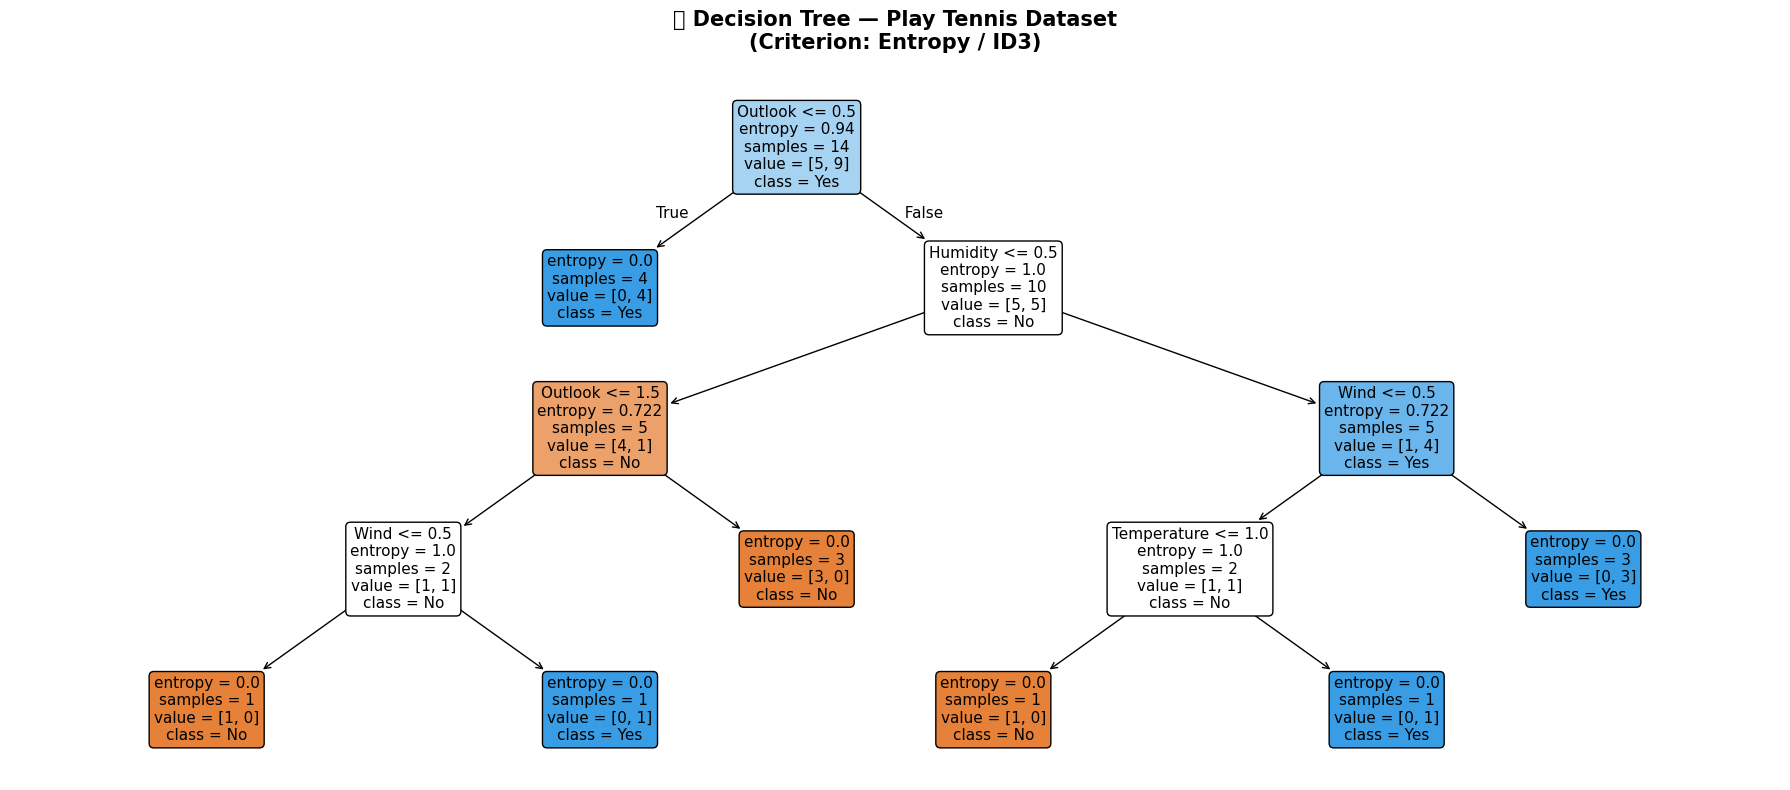

✅ Decision Tree saved as 'decision_tree.png'


In [7]:
# ── Plot Decision Tree ────────────────────────────────────────
plt.figure(figsize=(18, 8))
plot_tree(
    clf,
    feature_names=features,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=11,
    impurity=True,
    proportion=False
)
plt.title("🌳 Decision Tree — Play Tennis Dataset\n(Criterion: Entropy / ID3)",
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Decision Tree saved as 'decision_tree.png'")

# Information Gain Bar Chart
We plot a bar chart comparing the information gain of all four features. The best feature is highlighted in green while the rest are shown in blue. The exact IG value is displayed on top of each bar, giving an instant visual comparison of which feature contributes the most to classification.

/tmp/ipykernel_629/2856862697.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_629/2856862697.py:24: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("information_gain.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


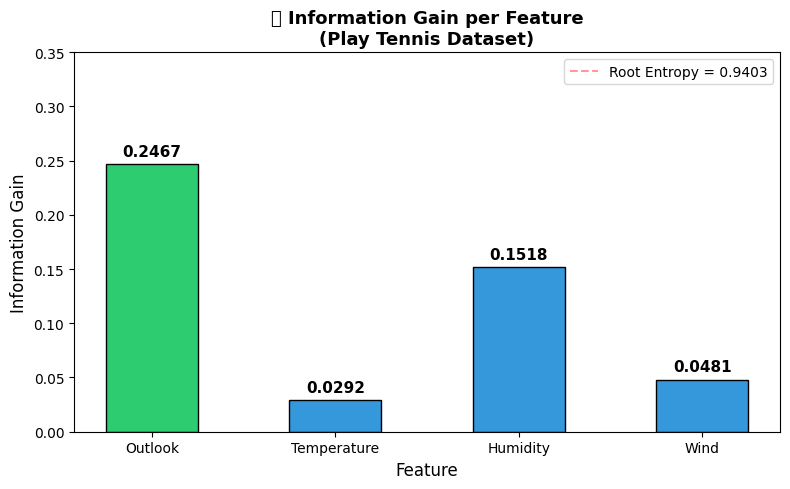

✅ Information Gain chart saved as 'information_gain.png'


In [8]:
# ── Information Gain Bar Chart ────────────────────────────────
plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if f == best_feature else '#3498db' for f in ig_results.keys()]
bars = plt.bar(ig_results.keys(), ig_results.values(),
               color=colors, edgecolor='black', width=0.5)

# Annotate bars
for bar, val in zip(bars, ig_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.title("📊 Information Gain per Feature\n(Play Tennis Dataset)",
          fontsize=13, fontweight='bold')
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Information Gain", fontsize=12)
plt.ylim(0, 0.35)
plt.axhline(y=total_ent, color='red', linestyle='--',
            alpha=0.4, label=f'Root Entropy = {total_ent:.4f}')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("information_gain.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Information Gain chart saved as 'information_gain.png'")

# Model Evaluation
We use clf.predict(X) to generate predictions on the training data and compare them against the actual labels. The accuracy score tells us the overall percentage of correct predictions. The classification report gives a deeper view showing precision, recall, and F1-score for each class. The confusion matrix is plotted as a heatmap showing exactly how many instances were correctly or incorrectly classified.


            🎯 MODEL EVALUATION

  Accuracy                : 100.00%
  Total Instances         : 14
  Correctly Classified    : 14

📋 Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         5
         Yes       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



/tmp/ipykernel_629/2514789711.py:25: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_629/2514789711.py:26: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


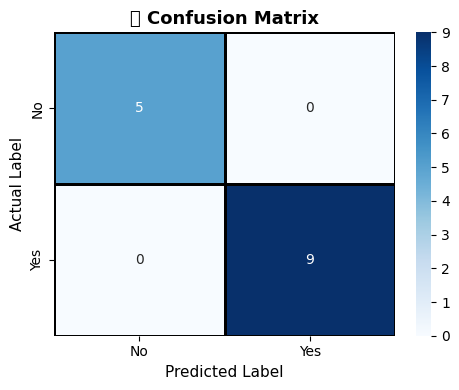

✅ Confusion Matrix saved as 'confusion_matrix.png'


In [9]:
# ── Predictions & Accuracy ────────────────────────────────────
y_pred = clf.predict(X)
acc = accuracy_score(y, y_pred)

print("\n" + "=" * 55)
print("            🎯 MODEL EVALUATION")
print("=" * 55)
print(f"\n  Accuracy                : {acc * 100:.2f}%")
print(f"  Total Instances         : {len(y)}")
print(f"  Correctly Classified    : {int(acc * len(y))}")

print("\n📋 Classification Report:")
print(classification_report(y, y_pred, target_names=['No', 'Yes']))

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'],
            linewidths=1, linecolor='black')
plt.title("🔢 Confusion Matrix", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion Matrix saved as 'confusion_matrix.png'")